In [4]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [5]:
df = pd.read_csv("train.csv")

print("Dataset Loaded Successfully!")

df.head()

Dataset Loaded Successfully!


,ID_code,target,var_0,var_1,var_2,var_3,var_4,var_5,var_6,var_7,...,var_190,var_191,var_192,var_193,var_194,var_195,var_196,var_197,var_198,var_199
0,train_0,0,8.9255,-6.7863,11.9081,5.0930,11.4607,-9.2834,5.1187,18.6266,...,4.4354,3.9642,3.1364,1.6910,18.5227,-2.3978,7.8784,8.5635,12.7803,-1.0914
1,train_1,0,11.5006,-4.1473,13.8588,5.3890,12.3622,7.0433,5.6208,16.5338,...,7.6421,7.7214,2.5837,10.9516,15.4305,2.0339,8.1267,8.7889,18.3560,1.9518
2,train_2,0,8.6093,-2.7457,12.0805,7.8928,10.5825,-9.0837,6.9427,14.6155,...,2.9057,9.7905,1.6704,1.6858,21.6042,3.1417,-6.5213,8.2675,14.7222,0.3965
3,train_3,0,11.0604,-2.1518,8.9522,7.1957,12.5846,-1.8361,5.8428,14.9250,...,4.4666,4.7433,0.7178,1.4214,23.0347,-1.2706,-2.9275,10.2922,17.9697,-8.9996
4,train_4,0,9.8369,-1.4834,12.8746,6.6375,12.2772,2.4486,5.9405,19.2514,...,-1.4905,9.5214,-0.1508,9.1942,13.2876,-1.5121,3.9267,9.5031,17.9974,-8.8104


In [6]:
print("Shape of Dataset:")
print(df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nDataset Information:")
df.info()

Shape of Dataset:
(200000, 202)

Column Names:
Index(['ID_code', 'target', 'var_0', 'var_1', 'var_2', 'var_3', 'var_4',
       'var_5', 'var_6', 'var_7',
       ...
       'var_190', 'var_191', 'var_192', 'var_193', 'var_194', 'var_195',
       'var_196', 'var_197', 'var_198', 'var_199'],
      dtype='str', length=202)

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Columns: 202 entries, ID_code to var_199
dtypes: float64(200), int64(1), str(1)
memory usage: 308.2 MB


In [7]:
print("Missing Values in Each Column:\n")

print(df.isnull().sum())

Missing Values in Each Column:

ID_code    0
target     0
var_0      0
var_1      0
var_2      0
          ..
var_195    0
var_196    0
var_197    0
var_198    0
var_199    0
Length: 202, dtype: int64


target
0    179902
1     20098
Name: count, dtype: int64


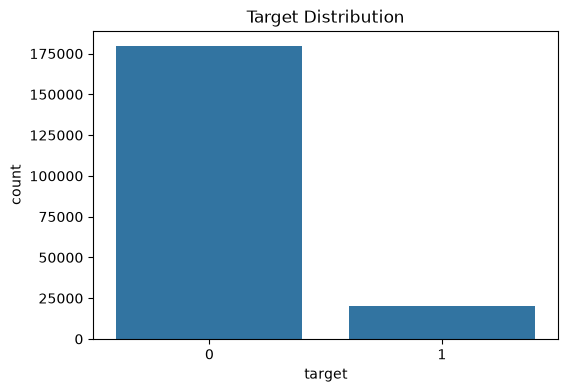

In [8]:
print(df["target"].value_counts())

plt.figure(figsize=(6,4))

sns.countplot(x="target", data=df)

plt.title("Target Distribution")

plt.show()


In [19]:
# Features (Input)
X = df.drop(["ID_code", "target"], axis=1)

# Target (Output)
y = df["target"]

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (200000, 203)
Target Shape: (200000,)


In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Features:", X_train.shape)
print("Testing Features:", X_test.shape)
print("Training Target:", y_train.shape)
print("Testing Target:", y_test.shape)

Training Features: (160000, 203)
Testing Features: (40000, 203)
Training Target: (160000,)
Testing Target: (40000,)


In [21]:
model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

model.fit(X_train, y_train)

print("Logistic Regression Model Trained Successfully!")

Logistic Regression Model Trained Successfully!


c:\Users\SARVESH_SUDHEER\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [22]:
y_pred = model.predict(X_test)

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))

Accuracy : 0.9141
Precision: 0.6850443599493029
Recall   : 0.2689054726368159
F1 Score : 0.38620936048588783


In [23]:
from sklearn.preprocessing import StandardScaler

# Scale the features
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [25]:
# Improved Logistic Regression

model = LogisticRegression(
    C=2,
    solver="liblinear",
    class_weight="balanced",
    max_iter=5000,
    random_state=42
)

model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))

Accuracy : 0.78855
Precision: 0.29261682242990655
Recall   : 0.7788557213930348
F1 Score : 0.4254076086956522


In [26]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "C": [0.1, 1, 2, 5, 10],
    "solver": ["liblinear", "lbfgs"],
    "class_weight": [None, "balanced"]
}

grid = GridSearchCV(
    LogisticRegression(max_iter=5000, random_state=42),
    param_grid,
    scoring="recall",
    cv=3,
    n_jobs=-1
)

grid.fit(X_train_scaled, y_train)

print("Best Parameters:", grid.best_params_)
print("Best Recall (CV):", grid.best_score_)

Best Parameters: {'C': 0.1, 'class_weight': 'balanced', 'solver': 'liblinear'}
Best Recall (CV): 0.7762161621450501


In [28]:
best_model = grid.best_estimator_

y_pred = best_model.predict(X_test_scaled)

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report")
print(classification_report(y_test, y_pred))

Accuracy : 0.788575
Precision: 0.2926441723525563
Recall   : 0.7788557213930348
F1 Score : 0.4254365106325158

Confusion Matrix
[[28412  7568]
 [  889  3131]]

Classification Report
              precision    recall  f1-score   support

           0       0.97      0.79      0.87     35980
           1       0.29      0.78      0.43      4020

    accuracy                           0.79     40000
   macro avg       0.63      0.78      0.65     40000
weighted avg       0.90      0.79      0.83     40000



In [17]:
# Mean of all features
df["feature_mean"] = df.iloc[:, 2:].mean(axis=1)

# Standard deviation of all features
df["feature_std"] = df.iloc[:, 2:].std(axis=1)

# Maximum feature value
df["feature_max"] = df.iloc[:, 2:].max(axis=1)

print("New Features Created Successfully!")

df.head()

C:\Users\SARVESH_SUDHEER\AppData\Local\Temp\ipykernel_19960\3910684887.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["feature_mean"] = df.iloc[:, 2:].mean(axis=1)
C:\Users\SARVESH_SUDHEER\AppData\Local\Temp\ipykernel_19960\3910684887.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["feature_std"] = df.iloc[:, 2:].std(axis=1)


New Features Created Successfully!


C:\Users\SARVESH_SUDHEER\AppData\Local\Temp\ipykernel_19960\3910684887.py:8: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["feature_max"] = df.iloc[:, 2:].max(axis=1)


,ID_code,target,var_0,var_1,var_2,var_3,var_4,var_5,var_6,var_7,...,var_193,var_194,var_195,var_196,var_197,var_198,var_199,feature_mean,feature_std,feature_max
0,train_0,0,8.9255,-6.7863,11.9081,5.0930,11.4607,-9.2834,5.1187,18.6266,...,1.6910,18.5227,-2.3978,7.8784,8.5635,12.7803,-1.0914,7.281591,9.308182,43.1127
1,train_1,0,11.5006,-4.1473,13.8588,5.3890,12.3622,7.0433,5.6208,16.5338,...,10.9516,15.4305,2.0339,8.1267,8.7889,18.3560,1.9518,7.076818,10.310257,40.5632
2,train_2,0,8.6093,-2.7457,12.0805,7.8928,10.5825,-9.0837,6.9427,14.6155,...,1.6858,21.6042,3.1417,-6.5213,8.2675,14.7222,0.3965,6.204483,8.731476,33.8820
3,train_3,0,11.0604,-2.1518,8.9522,7.1957,12.5846,-1.8361,5.8428,14.9250,...,1.4214,23.0347,-1.2706,-2.9275,10.2922,17.9697,-8.9996,6.441159,9.570048,38.1015
4,train_4,0,9.8369,-1.4834,12.8746,6.6375,12.2772,2.4486,5.9405,19.2514,...,9.1942,13.2876,-1.5121,3.9267,9.5031,17.9974,-8.8104,6.771155,11.258868,41.1037
